## Q3 - MLP on CIFAR-10 (PyTorch)


Imports & Device Setup

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
import torchvision.transforms as T

## Part (a)

Transform (Simple Normalization)

In [ ]:
# Normalization to [-1, 1]
transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

Load CIFAR-10 Dataset

In [3]:
# Part (a): Load dataset and normalize to [0,1]
transform = T.ToTensor()

train_set = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
test_set  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

print("Train samples:", len(train_set))
print("Test samples :", len(test_set))
print("Classes:", train_set.classes)


100.0%


Train samples: 50000
Test samples : 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


DataLoaders

In [9]:
batch_size = 128

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_set, batch_size=batch_size, shuffle=False)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

Train batches: 391
Test batches : 79


Show 5 Images per Class

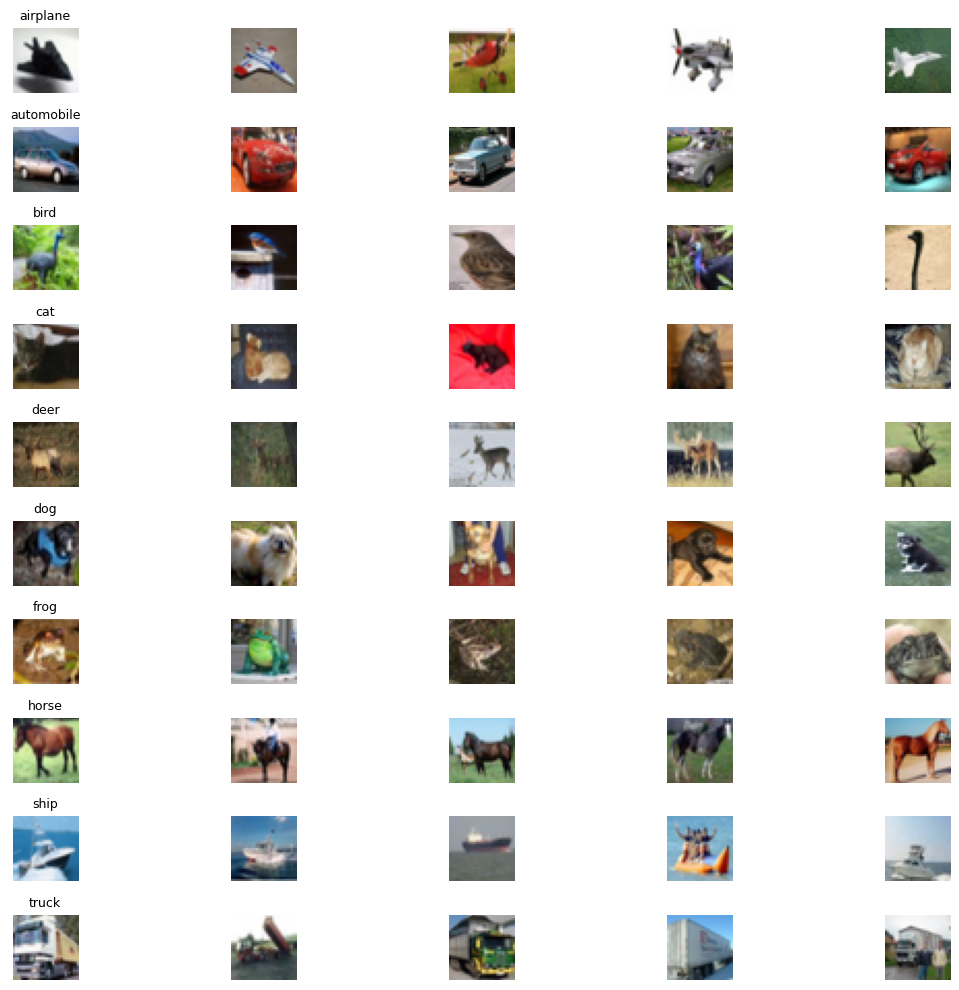

In [ ]:
# Part (a): Show 5 images per class
def unnormalize(img):
    return img * 0.5 + 0.5

classes = train_set.classes
n_per_class = 5

plt.figure(figsize=(12, 10))
shown = {i: 0 for i in range(10)}
idx = 0

while True:
    img, label = train_set[idx]
    if shown[label] < n_per_class:
        img_show = unnormalize(img)
        plt.subplot(10, n_per_class, label * n_per_class + shown[label] + 1)
        plt.imshow(img.permute(1, 2, 0))
        plt.axis("off")
        if shown[label] == 0:
            plt.title(classes[label], fontsize=9)
        shown[label] += 1
    if all(shown[i] == n_per_class for i in shown):
        break
    idx += 1

plt.tight_layout()
plt.show()


# Part (b) - Define MLP model

### Model Architecture (Given)

- Input: 32×32×3 = 3072
- FC1: 256 + ReLU
- FC2: 128 + Tanh
- FC3: 64  + ReLU
- Output: 10 logits


Define Model with nn.Sequential

In [8]:
# Define MLP model

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.Tanh(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)   # logits
)


Parameter Count

In [7]:
total_params = 0

for name, layer in model.named_modules():
    if isinstance(layer, nn.Linear):
        w = layer.weight.numel()
        b = layer.bias.numel()
        print(f"{name}: weights={w}, bias={b}, total={w+b}")
        total_params += (w + b)

print("Total learnable parameters:", total_params)

1: weights=786432, bias=256, total=786688
3: weights=32768, bias=128, total=32896
5: weights=8192, bias=64, total=8256
7: weights=640, bias=10, total=650
Total learnable parameters: 828490


# Part (c) - Training and Evaluation

Loss and Optimizer

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
EPOCHS = 30

train_losses, test_losses = [], []
train_accs, test_accs = [], []

for epoch in range(EPOCHS):
    # Train
    model.train()
    train_loss_sum = 0
    correct = 0
    total = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = train_loss_sum / len(train_loader)
    train_acc = correct / total

    # Test
    model.eval()
    test_loss_sum = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            logits = model(x)
            loss = criterion(logits, y)

            test_loss_sum += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    test_loss = test_loss_sum / len(test_loader)
    test_acc = correct / total

    train_losses.append(train_loss)
    test_losses.append(test_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1:02d} | "
          f"Train Loss={train_loss:.4f}, Train Acc={train_acc:.4f} | "
          f"Test Loss={test_loss:.4f}, Test Acc={test_acc:.4f}")


Epoch 01 | Train Loss=1.8915, Train Acc=0.3098 | Test Loss=1.7635, Test Acc=0.3535
Epoch 02 | Train Loss=1.6839, Train Acc=0.3930 | Test Loss=1.5982, Test Acc=0.4300
Epoch 03 | Train Loss=1.5943, Train Acc=0.4284 | Test Loss=1.5480, Test Acc=0.4386
Epoch 04 | Train Loss=1.5273, Train Acc=0.4538 | Test Loss=1.5214, Test Acc=0.4563
Epoch 05 | Train Loss=1.4839, Train Acc=0.4667 | Test Loss=1.4833, Test Acc=0.4671
Epoch 06 | Train Loss=1.4511, Train Acc=0.4794 | Test Loss=1.4733, Test Acc=0.4766
Epoch 07 | Train Loss=1.4254, Train Acc=0.4899 | Test Loss=1.4643, Test Acc=0.4781
Epoch 08 | Train Loss=1.3962, Train Acc=0.4983 | Test Loss=1.4428, Test Acc=0.4838
Epoch 09 | Train Loss=1.3710, Train Acc=0.5079 | Test Loss=1.4212, Test Acc=0.4914
Epoch 10 | Train Loss=1.3572, Train Acc=0.5143 | Test Loss=1.4179, Test Acc=0.4974
Epoch 11 | Train Loss=1.3332, Train Acc=0.5227 | Test Loss=1.4190, Test Acc=0.4945
Epoch 12 | Train Loss=1.3204, Train Acc=0.5276 | Test Loss=1.3963, Test Acc=0.5049
Epoc

Plot Curves

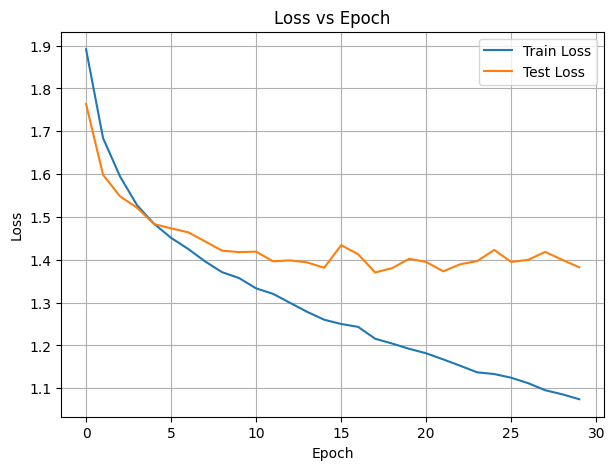

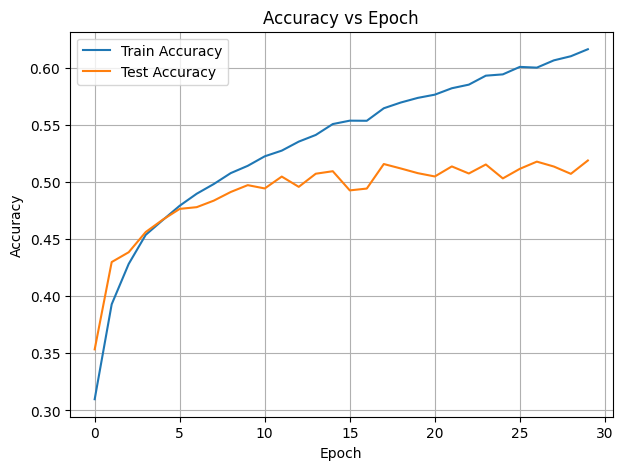

In [11]:
# Plot loss curves
plt.figure(figsize=(7, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch")
plt.grid(True)
plt.legend()
plt.show()

# Plot accuracy curves
plt.figure(figsize=(7, 5))
plt.plot(train_accs, label="Train Accuracy")
plt.plot(test_accs, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Epoch")
plt.grid(True)
plt.legend()
plt.show()


# Part (e) - Learning Rate + Dropout

In [12]:
# Baseline results are assumed to exist from previous parts:
# train_losses, test_losses, train_accs, test_accs (for lr=0.001, no dropout, no augmentation)

print("Baseline (lr=0.001) final train acc:", train_accs[-1])
print("Baseline (lr=0.001) final test  acc:", test_accs[-1])
print("Baseline (lr=0.001) final train loss:", train_losses[-1])
print("Baseline (lr=0.001) final test  loss:", test_losses[-1])

Baseline (lr=0.001) final train acc: 0.6165
Baseline (lr=0.001) final test  acc: 0.519
Baseline (lr=0.001) final train loss: 1.0744614395339165
Baseline (lr=0.001) final test  loss: 1.3825284499156325


## Train Again with a Different Learning Rate (e.g., 0.01)

In [13]:
# Experiment 1: Change learning rate (keep architecture the same, no dropout)
# Here we test lr=0.01 to see the effect, while baseline already used lr=0.001.

lr_test = 0.01
EPOCHS = 30

model_lr = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.Tanh(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_lr.parameters(), lr=lr_test)

train_losses_lr, test_losses_lr = [], []
train_accs_lr, test_accs_lr = [], []

for epoch in range(EPOCHS):
    # Train
    model_lr.train()
    train_loss_sum = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        logits = model_lr(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = train_loss_sum / len(train_loader)
    train_acc = correct / total

    # Test
    model_lr.eval()
    test_loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            logits = model_lr(x)
            loss = criterion(logits, y)

            test_loss_sum += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    test_loss = test_loss_sum / len(test_loader)
    test_acc = correct / total

    train_losses_lr.append(train_loss)
    test_losses_lr.append(test_loss)
    train_accs_lr.append(train_acc)
    test_accs_lr.append(test_acc)

    print(f"[lr={lr_test}] Epoch {epoch+1:02d} | "
          f"Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f} | "
          f"Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}")


[lr=0.01] Epoch 01 | Train Acc=0.0989, Test Acc=0.1000 | Train Loss=2.3050, Test Loss=2.3038
[lr=0.01] Epoch 02 | Train Acc=0.0964, Test Acc=0.1000 | Train Loss=2.3036, Test Loss=2.3031
[lr=0.01] Epoch 03 | Train Acc=0.1003, Test Acc=0.1000 | Train Loss=2.3032, Test Loss=2.3029
[lr=0.01] Epoch 04 | Train Acc=0.0988, Test Acc=0.1000 | Train Loss=2.3033, Test Loss=2.3029
[lr=0.01] Epoch 05 | Train Acc=0.0981, Test Acc=0.1000 | Train Loss=2.3033, Test Loss=2.3035
[lr=0.01] Epoch 06 | Train Acc=0.1004, Test Acc=0.1000 | Train Loss=2.3033, Test Loss=2.3032
[lr=0.01] Epoch 07 | Train Acc=0.0973, Test Acc=0.1000 | Train Loss=2.3034, Test Loss=2.3036
[lr=0.01] Epoch 08 | Train Acc=0.0989, Test Acc=0.1000 | Train Loss=2.3034, Test Loss=2.3030
[lr=0.01] Epoch 09 | Train Acc=0.0997, Test Acc=0.1000 | Train Loss=2.3033, Test Loss=2.3030
[lr=0.01] Epoch 10 | Train Acc=0.0991, Test Acc=0.1000 | Train Loss=2.3033, Test Loss=2.3031
[lr=0.01] Epoch 11 | Train Acc=0.0985, Test Acc=0.1000 | Train Loss=2.

Plot Baseline vs New Learning Rate

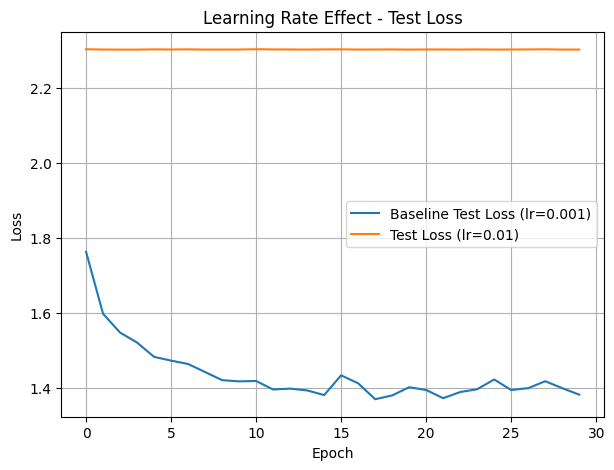

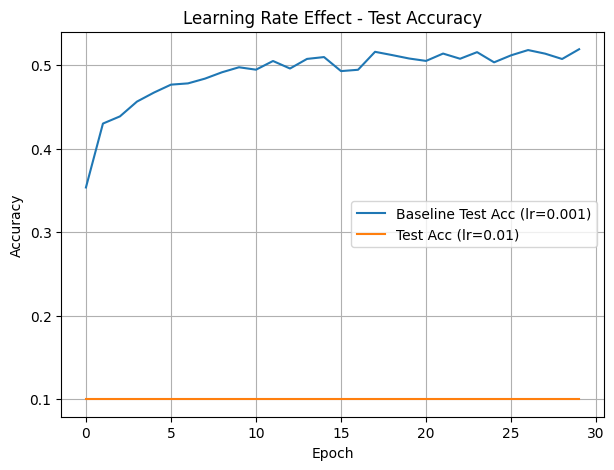

Baseline final test acc: 0.519
lr=0.01 final test acc: 0.1


In [14]:
# Compare baseline (lr=0.001) vs new lr
plt.figure(figsize=(7,5))
plt.plot(test_losses, label="Baseline Test Loss (lr=0.001)")
plt.plot(test_losses_lr, label=f"Test Loss (lr={lr_test})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Effect - Test Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(test_accs, label="Baseline Test Acc (lr=0.001)")
plt.plot(test_accs_lr, label=f"Test Acc (lr={lr_test})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Learning Rate Effect - Test Accuracy")
plt.grid(True)
plt.legend()
plt.show()

print("Baseline final test acc:", test_accs[-1])
print(f"lr={lr_test} final test acc:", test_accs_lr[-1])


## Train with Dropout (Same lr=0.001)

In [15]:
# Experiment 2: Add Dropout (keep lr=0.001 as requested)
drop_p = 0.25
EPOCHS = 30
lr_dropout = 0.001

model_do = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 256),
    nn.ReLU(),
    nn.Dropout(p=drop_p),

    nn.Linear(256, 128),
    nn.Tanh(),
    nn.Dropout(p=drop_p),

    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Dropout(p=drop_p),

    nn.Linear(64, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_do.parameters(), lr=lr_dropout)

train_losses_do, test_losses_do = [], []
train_accs_do, test_accs_do = [], []

for epoch in range(EPOCHS):
    # Train
    model_do.train()
    train_loss_sum = 0.0
    correct = 0
    total = 0

    for x, y in train_loader:
        optimizer.zero_grad()
        logits = model_do(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = train_loss_sum / len(train_loader)
    train_acc = correct / total

    # Test
    model_do.eval()
    test_loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader:
            logits = model_do(x)
            loss = criterion(logits, y)

            test_loss_sum += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    test_loss = test_loss_sum / len(test_loader)
    test_acc = correct / total

    train_losses_do.append(train_loss)
    test_losses_do.append(test_loss)
    train_accs_do.append(train_acc)
    test_accs_do.append(test_acc)

    print(f"[Dropout p={drop_p}] Epoch {epoch+1:02d} | "
          f"Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f} | "
          f"Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}")


[Dropout p=0.25] Epoch 01 | Train Acc=0.2524, Test Acc=0.3369 | Train Loss=2.0069, Test Loss=1.8124
[Dropout p=0.25] Epoch 02 | Train Acc=0.3339, Test Acc=0.3778 | Train Loss=1.8349, Test Loss=1.7194
[Dropout p=0.25] Epoch 03 | Train Acc=0.3559, Test Acc=0.4025 | Train Loss=1.7864, Test Loss=1.6557
[Dropout p=0.25] Epoch 04 | Train Acc=0.3669, Test Acc=0.4114 | Train Loss=1.7543, Test Loss=1.6433
[Dropout p=0.25] Epoch 05 | Train Acc=0.3775, Test Acc=0.4169 | Train Loss=1.7311, Test Loss=1.6166
[Dropout p=0.25] Epoch 06 | Train Acc=0.3873, Test Acc=0.4130 | Train Loss=1.7036, Test Loss=1.6158
[Dropout p=0.25] Epoch 07 | Train Acc=0.3918, Test Acc=0.4365 | Train Loss=1.6923, Test Loss=1.5637
[Dropout p=0.25] Epoch 08 | Train Acc=0.3991, Test Acc=0.4279 | Train Loss=1.6671, Test Loss=1.5857
[Dropout p=0.25] Epoch 09 | Train Acc=0.4030, Test Acc=0.4390 | Train Loss=1.6620, Test Loss=1.5627
[Dropout p=0.25] Epoch 10 | Train Acc=0.4071, Test Acc=0.4453 | Train Loss=1.6512, Test Loss=1.5368


Plot Baseline vs Dropout

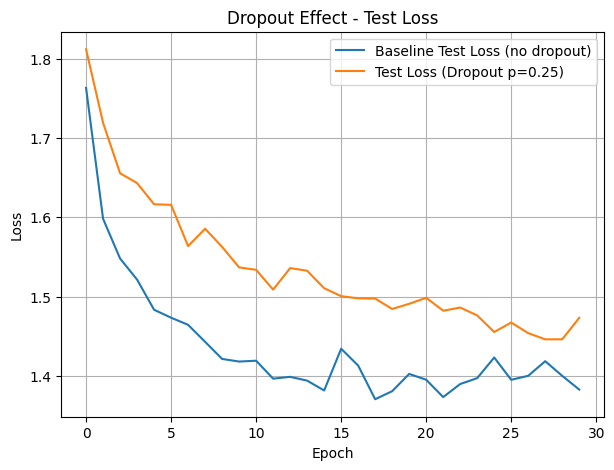

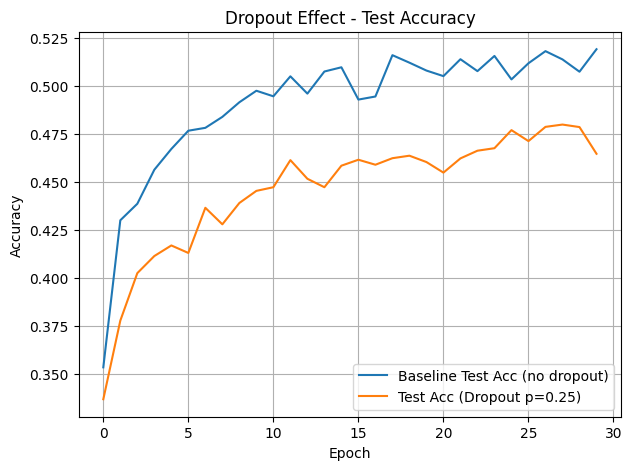

Baseline final test acc: 0.519
Dropout final test acc: 0.4646


In [16]:
plt.figure(figsize=(7,5))
plt.plot(test_losses, label="Baseline Test Loss (no dropout)")
plt.plot(test_losses_do, label=f"Test Loss (Dropout p={drop_p})")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Dropout Effect - Test Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(test_accs, label="Baseline Test Acc (no dropout)")
plt.plot(test_accs_do, label=f"Test Acc (Dropout p={drop_p})")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Dropout Effect - Test Accuracy")
plt.grid(True)
plt.legend()
plt.show()

print("Baseline final test acc:", test_accs[-1])
print("Dropout final test acc:", test_accs_do[-1])


# Part (f) - Data Augmentation and Retraining

In [17]:
# Data Augmentation for training set
transform_train_aug = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

# Test transform should NOT include augmentation
transform_test = T.Compose([
    T.ToTensor(),
    T.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

data_root = "./data"

train_set_aug = torchvision.datasets.CIFAR10(
    root=data_root, train=True, download=True, transform=transform_train_aug
)
test_set_noaug = torchvision.datasets.CIFAR10(
    root=data_root, train=False, download=True, transform=transform_test
)

batch_size = 128
train_loader_aug = DataLoader(train_set_aug, batch_size=batch_size, shuffle=True)
test_loader_noaug = DataLoader(test_set_noaug, batch_size=batch_size, shuffle=False)

print("Augmented train samples:", len(train_set_aug))
print("Test samples:", len(test_set_noaug))


Augmented train samples: 50000
Test samples: 10000


Retrain Same MLP with Augmented Data

In [18]:
# Retrain the SAME baseline architecture with augmented training data
EPOCHS = 30
lr_aug = 0.001

model_aug = nn.Sequential(
    nn.Flatten(),
    nn.Linear(32*32*3, 256),
    nn.ReLU(),
    nn.Linear(256, 128),
    nn.Tanh(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_aug.parameters(), lr=lr_aug)

train_losses_aug, test_losses_aug = [], []
train_accs_aug, test_accs_aug = [], []

for epoch in range(EPOCHS):
    # Train
    model_aug.train()
    train_loss_sum = 0.0
    correct = 0
    total = 0

    for x, y in train_loader_aug:
        optimizer.zero_grad()
        logits = model_aug(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    train_loss = train_loss_sum / len(train_loader_aug)
    train_acc = correct / total

    # Test
    model_aug.eval()
    test_loss_sum = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in test_loader_noaug:
            logits = model_aug(x)
            loss = criterion(logits, y)

            test_loss_sum += loss.item()
            preds = torch.argmax(logits, dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    test_loss = test_loss_sum / len(test_loader_noaug)
    test_acc = correct / total

    train_losses_aug.append(train_loss)
    test_losses_aug.append(test_loss)
    train_accs_aug.append(train_acc)
    test_accs_aug.append(test_acc)

    print(f"[Augment] Epoch {epoch+1:02d} | "
          f"Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f} | "
          f"Train Loss={train_loss:.4f}, Test Loss={test_loss:.4f}")


[Augment] Epoch 01 | Train Acc=0.3257, Test Acc=0.3976 | Train Loss=1.8444, Test Loss=1.6870
[Augment] Epoch 02 | Train Acc=0.3892, Test Acc=0.4074 | Train Loss=1.6796, Test Loss=1.6821
[Augment] Epoch 03 | Train Acc=0.4167, Test Acc=0.4140 | Train Loss=1.6120, Test Loss=1.6286
[Augment] Epoch 04 | Train Acc=0.4321, Test Acc=0.4351 | Train Loss=1.5705, Test Loss=1.5944
[Augment] Epoch 05 | Train Acc=0.4408, Test Acc=0.4348 | Train Loss=1.5472, Test Loss=1.5874
[Augment] Epoch 06 | Train Acc=0.4459, Test Acc=0.4424 | Train Loss=1.5272, Test Loss=1.5502
[Augment] Epoch 07 | Train Acc=0.4500, Test Acc=0.4389 | Train Loss=1.5166, Test Loss=1.5618
[Augment] Epoch 08 | Train Acc=0.4614, Test Acc=0.4514 | Train Loss=1.4974, Test Loss=1.5351
[Augment] Epoch 09 | Train Acc=0.4610, Test Acc=0.4396 | Train Loss=1.4886, Test Loss=1.5530
[Augment] Epoch 10 | Train Acc=0.4682, Test Acc=0.4487 | Train Loss=1.4778, Test Loss=1.5462
[Augment] Epoch 11 | Train Acc=0.4705, Test Acc=0.4514 | Train Loss=1.

Compare Baseline vs Augmentation

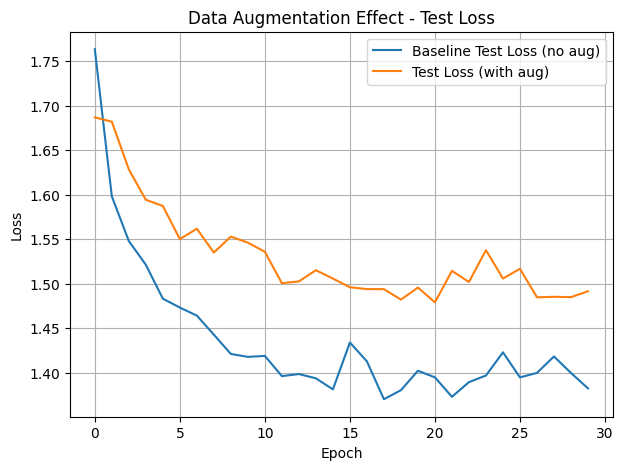

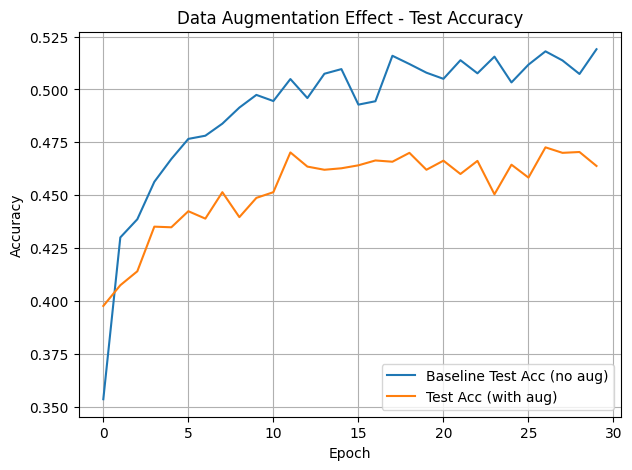

Baseline final test acc: 0.519
Augmented final test acc: 0.4638


In [19]:
plt.figure(figsize=(7,5))
plt.plot(test_losses, label="Baseline Test Loss (no aug)")
plt.plot(test_losses_aug, label="Test Loss (with aug)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Data Augmentation Effect - Test Loss")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(7,5))
plt.plot(test_accs, label="Baseline Test Acc (no aug)")
plt.plot(test_accs_aug, label="Test Acc (with aug)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Data Augmentation Effect - Test Accuracy")
plt.grid(True)
plt.legend()
plt.show()

print("Baseline final test acc:", test_accs[-1])
print("Augmented final test acc:", test_accs_aug[-1])
